In [1]:
import os
from dataset import load_dataset
import joblib
from regression.RandomForest.random_forest_regression import RandomForestRegressorModel
from regression.probabilistic_rf_scoring import fit_rank_pdfs_loglik
from regression.probabilistic_rf_scoring import plot_ranked_pdfs
from regression.probabilistic_rf_scoring import plot_pdf_with_true_target
from sklearn.inspection import PartialDependenceDisplay
from sklearn.inspection import permutation_importance
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("default")
from plot_style import set_plot_style
from regression.probabilistic_rf_scoring import fit_best_pdf
set_plot_style()

In [2]:
TARGET_COL = "trq_target"
FEATURES=["trq_measured","mgt","ias","oat","np_ng_ratio","pa"]
TRAIN_PATH_SPLIT= "../../../../data/processed/split_85_15/train_85.csv"
TEST_PATH_SPLIT= "../../../../data/processed/split_85_15/test_15.csv"
OUTPUT_PATH= "../../../../output/random_forest_regressor/model_target/"
MODEL_PATH="random_forest_model_target.pkl"
METRIC_TRAIN="metric_train.csv"
METRIC_TEST="metric_test.csv"

In [3]:
train_df = load_dataset(TRAIN_PATH_SPLIT)
test_df = load_dataset(TEST_PATH_SPLIT)

X_train = train_df[FEATURES].values
y_train = train_df[TARGET_COL].values

X_test = test_df[FEATURES].values
y_test = test_df[TARGET_COL].values

In [4]:
rf_model = RandomForestRegressorModel(
    n_estimators=500,
    min_samples_leaf=3,
)

if os.path.exists(OUTPUT_PATH+MODEL_PATH):
    rf_model=joblib.load(OUTPUT_PATH+MODEL_PATH)
else:
    rf_model.fit(X_train, y_train)
    joblib.dump(rf_model, OUTPUT_PATH + MODEL_PATH)

In [5]:
metric_train=rf_model.evaluate(X_train, y_train,"train")
df_metric_train = pd.DataFrame([metric_train])
df_metric_train.to_csv(OUTPUT_PATH+METRIC_TRAIN, index=False)

metric_validate=rf_model.evaluate(X_test, y_test,"test")
df_metric_test = pd.DataFrame([metric_validate])
df_metric_test.to_csv(OUTPUT_PATH+METRIC_TEST, index=False)


Metrics on train
MAE  : 0.077253
RMSE : 0.139105
R²   : 0.999903

Metrics on test
MAE  : 0.126155
RMSE : 0.218526
R²   : 0.999764


In [5]:
id=100
test_row=test_df.iloc[id]
torque_measured=test_row['trq_measured']
torque_margin_true=test_row['trq_margin']
testX = test_df.loc[[id], FEATURES].to_numpy()
trq_target_pred = rf_model.predict_mean(testX)
trq_margin_pred = (torque_measured /  trq_target_pred - 1) * 100
tree_preds = rf_model.predict_trees(testX)
tree_preds["trq_margin_pred"] = (torque_measured / tree_preds["trq_target_prediction"] - 1) * 100
tree_preds.head()

Python(16372) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


,trq_target_prediction,trq_margin_pred
0,72.162626,-6.045548
1,72.653279,-6.680055
2,72.303127,-6.228122
3,72.435951,-6.400069
4,72.114235,-5.982502


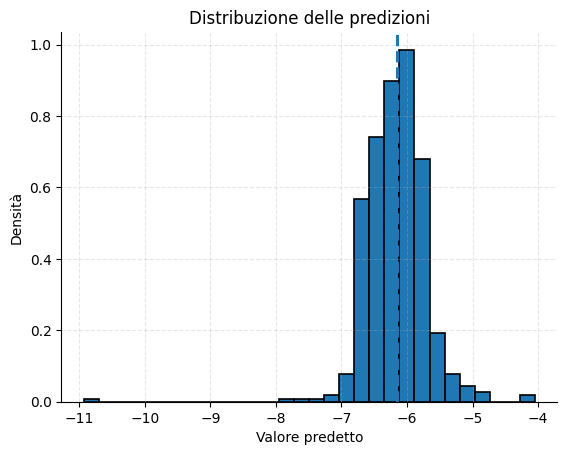

In [6]:
plt.figure()
plt.hist(tree_preds["trq_margin_pred"], bins=30, density=True)
plt.axvline(np.median(tree_preds["trq_margin_pred"]), linestyle="--", label="Predizione puntuale")
plt.xlabel("Valore predetto")
plt.xlabel("Valore predetto")
plt.ylabel("Densità")
plt.title("Distribuzione delle predizioni")
plt.show()

In [7]:
best,results= fit_best_pdf(tree_preds["trq_margin_pred"])

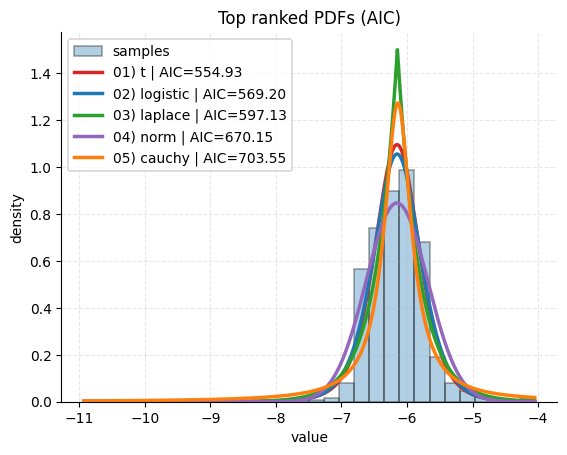

In [8]:
plot_ranked_pdfs(results,tree_preds["trq_margin_pred"])

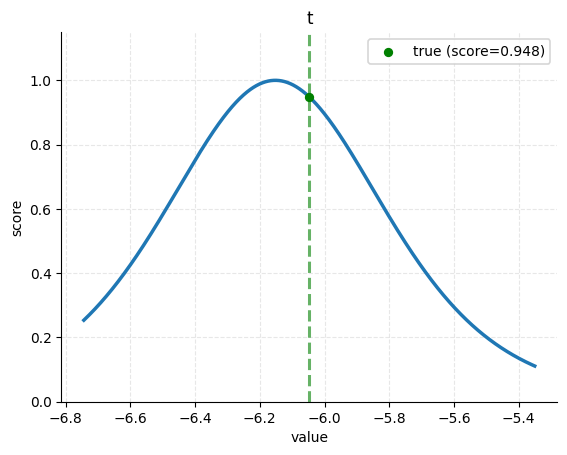

{'pdf_type': 't',
 'true_target': -6.047048375117549,
 'prediction': None,
 'score_true': 0.9484188146813504,
 'score_pred': None,
 'x_range': (-6.743750211942278, -5.350346538292819)}

In [9]:
plot_pdf_with_true_target(best["pdf_type"],best["pdf_args"],torque_margin_true,None)

In [5]:
predict_test=rf_model.predict_mean_all(test_df,test_df["trq_margin"],FEATURES,keep_cols=["mgt","ias","oat","np_ng_ratio","pa","faulty"])

In [8]:
predict_test.to_csv(OUTPUT_PATH+"pred_margin_test.csv")